# Polar-is Query Demo

This notebook calls the implemented query functions:

* Timeseries
* Heatmap
* Find-time
* Find-area

We print the `QueryResult`, `GroupResult`, and `SourceInfo` of a result, and display the returned `xarray.Dataset` and plots when specified.

The executor also writes each returned group to its configured NetCDF output path.

## General functions

#### Driver: **`run_scenario(base_query, func_calls)`** - prints query results of all functions in `func_calls` of the given `base_query`

`find_project_root()` - determines the absolute directory path of Polar-is

`print_query_result()` - prints `QueryResult` information, prints group info individually

`plot_query_result()` - plots results of multiple groups

Helper functions:

* `sorted_coverage_cells()` - returns the bucket ID and the timestamp of cells
* `display_longitudes()` - converts longitudes from 0...360 to -180...180
* `projection_for_group()` - finds CRS for group
* `cell_polygon()` - make grid from flattened cells [WILL BE REPLACED WITH ORIGINAL x, y COORDINATES]
* `plot_spatial_values()` - plot heatmap; color edge red if find-area function
* `plot_group_result()` - plot one results of one group: for get-data, plots heatmap at the first timestamp


In [8]:
'''imports, find_project_root'''
from pathlib import Path
import sys

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import numpy as np
from IPython.display import display


def find_project_root():
    # This works when Jupyter starts either in the repository or beside this notebook.
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'config.yaml').is_file() and (candidate / 'storage').is_dir():
            return candidate
    raise RuntimeError('Start Jupyter from the polar-is repository or one of its subdirectories.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from storage.query_data.executor import execute_query

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/bean/Documents/school/research/current/polar-is


In [9]:
'''print_query_result()'''
def sorted_coverage_cells(cells):
    return [
        (bucket_id, timestamp.isoformat())
        for bucket_id, timestamp in sorted(cells, key=lambda item: (item[0], item[1]))
    ]


def print_query_result(result):
    print('QueryResult')
    print(f'  query_id: {result.query_id}')
    print(f'  function: {result.function}')
    print(f'  warnings: {list(result.warnings)}')
    print(f'  unmatched_miss_set: {sorted_coverage_cells(result.unmatched_miss_set)}')
    print(f'  groups: {len(result.groups)}')

    for number, group in enumerate(result.groups, start=1):
        print(f'\n  GroupResult {number}')
        print(f'\t    group_id: {group.group_id}')
        print(f'\t    file_path: {group.file_path}')
        print(f'\t    units: {group.units!r}')
        print(f'\t    hit_set: {sorted_coverage_cells(group.hit_set)}')
        print(f'\t    miss_set: {sorted_coverage_cells(group.miss_set)}')
        print(f'\t    warnings: {list(group.warnings)}')

        source = group.source
        print('    source:')
        print(f'      repository: {source.repository}')
        print(f'      dataset: {source.dataset}')
        print(f'      variable: {source.variable}')
        print(f'      additional_parameters: {source.additional_parameters}')
        print(f'      native_temporal_resolutions: {source.native_temporal_resolutions}')
        print(f'      native_spatial_resolutions: {source.native_spatial_resolutions}')
        print(f'      block_ids: {source.block_ids}')
        print('    data:')
        display(group.data)

In [10]:
'''plot_query_result()'''

GEOGRAPHIC_CRS = ccrs.PlateCarree()


def display_longitudes(longitudes):
    # Stored longitudes are 0..360; plotting at -180..180 is easier to read.
    return (np.asarray(longitudes) + 180.0) % 360.0 - 180.0


def projection_for_group(group):
    attrs = group.data[group.source.variable].attrs
    if attrs.get('GRIB_gridType') != 'lambert':
        return GEOGRAPHIC_CRS

    central_longitude = display_longitudes(
        float(attrs['GRIB_LoVInDegrees'])
    ).item()
    return ccrs.LambertConformal(
        central_longitude=central_longitude,
        central_latitude=float(attrs['GRIB_LaDInDegrees']),
        standard_parallels=(
            float(attrs['GRIB_Latin1InDegrees']),
            float(attrs['GRIB_Latin2InDegrees']),
        ),
    )


def cell_polygons(group, longitude, latitude):
    # Query results remain flattened cells. For plotting only, make one
    # rectangle around each center using the source grid's cell size.
    attrs = group.data[group.source.variable].attrs
    projection = projection_for_group(group)
    factor = float(group.data.attrs.get('coarseness_factor', 1))

    if attrs.get('GRIB_gridType') == 'lambert':
        centers = projection.transform_points(
            GEOGRAPHIC_CRS, longitude, latitude
        )[:, :2]
        x_center, y_center = centers[:, 0], centers[:, 1]
        half_width = float(attrs['GRIB_DxInMetres']) * factor / 2.0
        half_height = float(attrs['GRIB_DyInMetres']) * factor / 2.0
    else:
        x_center, y_center = longitude, latitude
        native_resolution = float(group.source.native_spatial_resolutions[0])
        half_width = native_resolution * factor / 2.0
        half_height = native_resolution * factor / 2.0

    vertices = np.stack(
        [
            np.column_stack((x_center - half_width, y_center - half_height)),
            np.column_stack((x_center + half_width, y_center - half_height)),
            np.column_stack((x_center + half_width, y_center + half_height)),
            np.column_stack((x_center - half_width, y_center + half_height)),
        ],
        axis=1,
    )
    return projection, vertices


def plot_spatial_values(
    group, values, title, cmap='viridis', colorbar_label=None, matches=None
):
    data = group.data
    longitude = display_longitudes(data['longitude'].values)
    latitude = np.asarray(data['latitude'].values)
    values = np.asarray(values)
    valid = np.isfinite(values) & np.isfinite(longitude) & np.isfinite(latitude)

    projection, vertices = cell_polygons(
        group, longitude[valid], latitude[valid]
    )
    fig, ax = plt.subplots(
        figsize=(8, 6), subplot_kw={'projection': projection}
    )
    cells = PolyCollection(
        vertices, array=values[valid], cmap=cmap, edgecolors='none',
        transform=projection,
    )
    ax.add_collection(cells)

    if valid.any():
        longitude_padding = max(np.ptp(longitude[valid]) * 0.03, 0.2)
        latitude_padding = max(np.ptp(latitude[valid]) * 0.03, 0.2)
        ax.set_extent(
            [
                longitude[valid].min() - longitude_padding,
                longitude[valid].max() + longitude_padding,
                max(-90.0, latitude[valid].min() - latitude_padding),
                min(90.0, latitude[valid].max() + latitude_padding),
            ],
            crs=GEOGRAPHIC_CRS,
        )
        colorbar = fig.colorbar(cells, ax=ax, format='%.3f')
        colorbar.set_label(colorbar_label or group.source.variable)

    if matches is not None:
        matched = valid & np.asarray(matches, dtype=bool)
        if matched.any():
            _, matched_vertices = cell_polygons(
                group, longitude[matched], latitude[matched]
            )
            outlines = PolyCollection(
                matched_vertices, facecolors='none', edgecolors='crimson',
                linewidths=0.8, transform=projection, zorder=2,
            )
            ax.add_collection(outlines)
            ax.legend(
                handles=[Patch(facecolor='none', edgecolor='crimson',
                               label='predicate matched')]
            )

    gridlines = ax.gridlines(draw_labels=True, alpha=0.25)
    gridlines.top_labels = False
    gridlines.right_labels = False
    ax.set_title(title)
    plt.show()


def plot_group_result(group, function, filter_value=None):
    data = group.data
    variable = group.source.variable
    label = variable if group.units is None else f'{variable} ({group.units})'
    source_label = f'{group.source.repository} / {group.source.dataset}'

    if function == 'get-data':
        if data.sizes.get('timestamp', 0) == 0:
            return
        first_time = data['timestamp'].values[0]
        plot_spatial_values(
            group,
            data[variable].isel(timestamp=0).values,
            f'get-data: {source_label} at {first_time}',
            colorbar_label=label,
        )

    elif function in {'timeseries', 'find-time'}:
        timestamps = data['timestamp'].values
        values = data[variable].values
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(timestamps, values, marker='.', label=variable)
        if function == 'find-time':
            matches = data['matches'].values.astype(bool)
            ax.scatter(
                timestamps[matches], values[matches], color='crimson',
                zorder=3, label='predicate matched'
            )
            ax.axhline(filter_value, color='crimson', linestyle='--', alpha=0.6,
                       label=f'filter value = {filter_value}')
        ax.set(xlabel='Time', ylabel=label, title=f'{function}: {source_label}')
        ax.grid(alpha=0.25)
        ax.legend()
        fig.autofmt_xdate()
        plt.show()

    elif function == 'heatmap':
        plot_spatial_values(
            group, data[variable].values, f'heatmap: {source_label}',
            colorbar_label=label,
        )

    elif function == 'find-area':
        plot_spatial_values(
            group, data[variable].values,
            f'find-area: {source_label}; filter value = {filter_value}',
            colorbar_label=label, matches=data['matches'].values,
        )


def plot_query_result(result, filter_value=None):
    if not result.groups:
        print('No group data was returned, so there is nothing to plot.')
        return
    for group in result.groups:
        plot_group_result(group, result.function, filter_value=filter_value)

In [11]:
'''run_scenario'''
def run_scenario(base_query, func_calls):
    results = {}
    for function, function_fields in func_calls:
        query = {**base_query, 'function': function, **function_fields}
        print('\n' + '=' * 100)
        print(f'{function}')
        print('=' * 100)
        print('Query input:')
        display(query)

        result = execute_query(query)
        print_query_result(result)
        plot_query_result(result, filter_value=function_fields.get('filter_value'))
        results[function] = result
    return results

#### Driver: **`run_multigroup_scenario()`** - 

Helper functions:
* `multiple_group_label()` - add label to multi-dataset plot 
* `spatial_values_for_function()` - return data values at first timestamp
* `draw_spatial_group_panel()`, `plot_spatial_groups_side_by_side()`, `plot_temporal_groups_side_by_side()`, `plot_multiple_group_result()` - plot a plot for each dataset returned

In [30]:
'''run_multigroup_scenario()'''
def multiple_group_label(group):
    label = f'{group.source.repository}\n{group.source.dataset}'
    if group.source.additional_parameters:
        parameters = ', '.join(
            f'{name}={value}'
            for name, value in sorted(group.source.additional_parameters.items())
        )
        label += f'\n{parameters}'
    return label


def spatial_values_for_function(group, function):
    values = group.data[group.source.variable]
    if function == 'get-data':
        values = values.isel(timestamp=0)
    return values.values


def draw_spatial_group_panel(ax, group, values, norm, region, matches=None):
    longitude = display_longitudes(group.data['longitude'].values)
    latitude = np.asarray(group.data['latitude'].values)
    values = np.asarray(values)
    valid = np.isfinite(values) & np.isfinite(longitude) & np.isfinite(latitude)
    projection, vertices = cell_polygons(
        group, longitude[valid], latitude[valid]
    )
    cells = PolyCollection(
        vertices, array=values[valid], cmap='viridis', norm=norm,
        edgecolors='none', transform=projection,
    )
    ax.add_collection(cells)
    ax.set_extent(
        [region['west'], region['east'], region['south'], region['north']],
        crs=GEOGRAPHIC_CRS,
    )
    ax.gridlines(alpha=0.2)
    ax.set_title(multiple_group_label(group), fontsize=9)

    if matches is not None:
        matched = valid & np.asarray(matches, dtype=bool)
        if matched.any():
            _, matched_vertices = cell_polygons(
                group, longitude[matched], latitude[matched]
            )
            ax.add_collection(
                PolyCollection(
                    matched_vertices, facecolors='none', edgecolors='crimson',
                    linewidths=0.7, transform=projection, zorder=2,
                )
            )
    return cells


def plot_spatial_groups_side_by_side(result, query):
    groups = sorted(
        result.groups,
        key=lambda group: (group.source.repository, group.source.dataset),
    )
    values_by_group = [
        spatial_values_for_function(group, result.function) for group in groups
    ]
    finite_values = np.concatenate(
        [values[np.isfinite(values)] for values in values_by_group]
    )
    norm = Normalize(vmin=finite_values.min(), vmax=finite_values.max())

    fig = plt.figure(figsize=(5 * len(groups), 5.5))
    axes = []
    mappable = None
    for number, (group, values) in enumerate(
        zip(groups, values_by_group), start=1
    ):
        ax = fig.add_subplot(
            1, len(groups), number, projection=projection_for_group(group)
        )
        matches = (
            group.data['matches'].values
            if result.function == 'find-area'
            else None
        )
        mappable = draw_spatial_group_panel(
            ax, group, values, norm, query['region'], matches=matches
        )
        axes.append(ax)

    units = next((group.units for group in groups if group.units), None)
    colorbar = fig.colorbar(
        mappable, ax=axes, orientation='horizontal', fraction=0.05,
        pad=0.12, format='%.1f',
    )
    colorbar.set_label(
        result.groups[0].source.variable
        if units is None
        else f'{result.groups[0].source.variable} ({units})'
    )
    title = result.function
    if result.function == 'get-data':
        title += f" at {groups[0].data['timestamp'].values[0]}"
    fig.suptitle(f'Multiple storage groups: {title}', fontsize=14)
    fig.subplots_adjust(top=0.80, bottom=0.22, wspace=0.12)
    plt.show()


def plot_temporal_groups_side_by_side(result, filter_value=None):
    groups = sorted(
        result.groups,
        key=lambda group: (group.source.repository, group.source.dataset),
    )
    fig, axes = plt.subplots(
        1, len(groups), figsize=(5 * len(groups), 4),
        sharex=True, sharey=True, squeeze=False,
    )
    for ax, group in zip(axes[0], groups):
        data = group.data
        variable = group.source.variable
        timestamps = data['timestamp'].values
        values = data[variable].values
        ax.plot(timestamps, values, marker='.', linewidth=1)
        if result.function == 'find-time':
            matches = data['matches'].values.astype(bool)
            ax.scatter(
                timestamps[matches], values[matches], color='crimson', zorder=3
            )
            ax.axhline(filter_value, color='crimson', linestyle='--', alpha=0.6)
        ax.set_title(multiple_group_label(group), fontsize=9)
        ax.grid(alpha=0.25)
        ax.tick_params(axis='x', labelrotation=35)

    units = next((group.units for group in groups if group.units), None)
    axes[0, 0].set_ylabel(
        groups[0].source.variable
        if units is None
        else f'{groups[0].source.variable} ({units})'
    )
    fig.suptitle(f'Multiple storage groups: {result.function}', fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_multiple_group_result(result, query, filter_value=None):
    if not result.groups:
        print('No group data was returned, so there is nothing to plot.')
    elif result.function in {'timeseries', 'find-time'}:
        plot_temporal_groups_side_by_side(result, filter_value=filter_value)
    else:
        plot_spatial_groups_side_by_side(result, query)

def run_multigroup_scenario(group_query, func_calls):

    multiple_group_results = {}
    for function, function_fields in func_calls:
        query = {
            **group_query,
            'function': function,
            **function_fields,
        }
        result = execute_query(query)
        multiple_group_results[function] = result

        print(f'\n{function}: {len(result.groups)} groups')
        for group in sorted(result.groups, key=lambda item: item.source.dataset):
            print(
                f"  {group.source.dataset}: {group.data.sizes}, "
                f"misses={len(group.miss_set)}"
            )
        for warning in result.warnings:
            print(f'  warning: {warning}')

        plot_multiple_group_result(
            result, query, filter_value=function_fields.get('filter_value')
        )

## Query specific dataset

#### Define `func_calls`

In [18]:
FILTER_VAL_TIME = 297.6
FILTER_VAL_SPACE = 298.0

PREDICATE_TIME = 'gt'
PREDICATE_SPACE = 'gt'

FUNCTION_CALLS = (
    ('get-data', {}),
    ('timeseries', {}),
    ('heatmap', {}),
    ('find-time', {'predicate': PREDICATE_TIME, 'filter_value': FILTER_VAL_TIME}),
    ('find-area', {'predicate': PREDICATE_SPACE, 'filter_value': FILTER_VAL_SPACE}),
)

#### Define `base_query`

In [19]:
COMMON_QUERY = {
    'variable': 'sea_surface_temperature',
    'time_start': '2018-01',
    'time_end': '2018-01',
    'coarseness_factor': 1,
    'time_unit': 'Day',
    'aggregation_method': 'mean',
}

NO_MISSES = {
    **COMMON_QUERY,
    'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'era5_single_level',
}

SOME_MISSES = {
    **COMMON_QUERY,
    'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'carra_height',
    'additional_parameters': {'height': '15m'},
}

ALL_MISSES = {
    **COMMON_QUERY,
    'region': {'west': 10.0, 'east': 20.0, 'south': -20.0, 'north': -10.0},
    'repository': 'copernicusclimatedatastore',
    'dataset': 'carra_height',
    'additional_parameters': {'height': '15m'},
}

# to display, use display({'str': base_query})

### Results

Calling ERA5 dataset: expecting all the data to be in storage, so there will be no misses and all (`bucket ID`, `timestamp`) tuples should be in `hit_set`.


get-data
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'get-data'}

QueryResult
  query_id: 68c676f6c0ed23f676ead2fcf3c29be0
  function: get-data
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: a01622840c54dfdaabc6d3dda165da4f
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/68c676f6c0ed23f676ead2fcf3c29be0/get-data/a01622840c54dfdaabc6d3dda165da4f.nc
	    units: 'K'
	    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-

<xarray.Dataset> Size: 144kB
Dimensions:                  (cell: 441, timestamp: 31)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp, cell) float64 109kB 298.5 ... 295.9
Attributes:
    query_id:               68c676f6c0ed23f676ead2fcf3c29be0
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               get-data
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

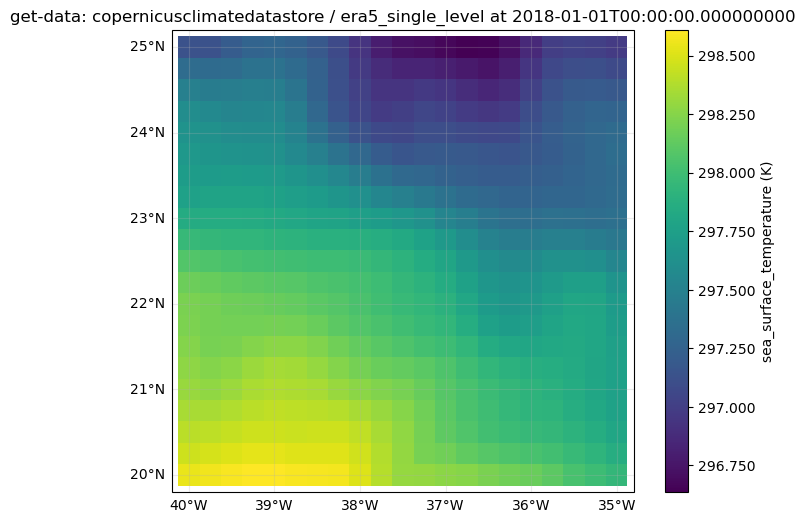


timeseries
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'timeseries'}

QueryResult
  query_id: 63f581e445b67ced31c0786e121f5416
  function: timeseries
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: a01622840c54dfdaabc6d3dda165da4f
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/63f581e445b67ced31c0786e121f5416/timeseries/a01622840c54dfdaabc6d3dda165da4f.nc
	    units: 'K'
	    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2

<xarray.Dataset> Size: 1kB
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 297.7 297.6 ... 296.6
Attributes:
    query_id:               63f581e445b67ced31c0786e121f5416
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               timeseries
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

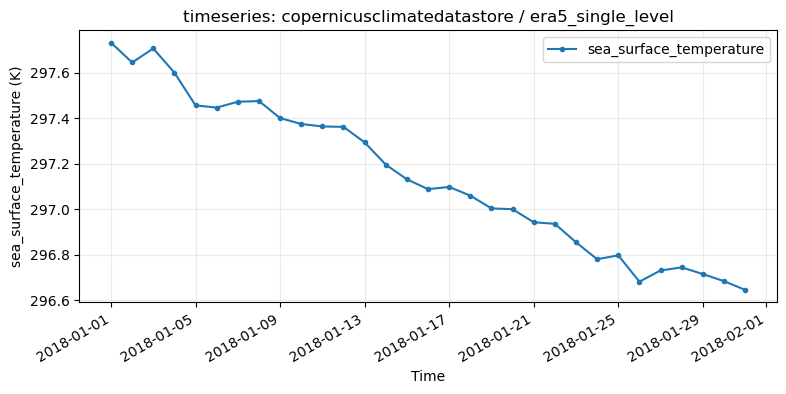


heatmap
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'heatmap'}

QueryResult
  query_id: 67ca1708a1ef0c2d5559092b19439db1
  function: heatmap
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: a01622840c54dfdaabc6d3dda165da4f
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/67ca1708a1ef0c2d5559092b19439db1/heatmap/a01622840c54dfdaabc6d3dda165da4f.nc
	    units: 'K'
	    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '2018-01

<xarray.Dataset> Size: 37kB
Dimensions:                  (cell: 441)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (cell) float64 4kB 298.1 298.1 ... 296.5 296.4
Attributes:
    query_id:               67ca1708a1ef0c2d5559092b19439db1
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               heatmap
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

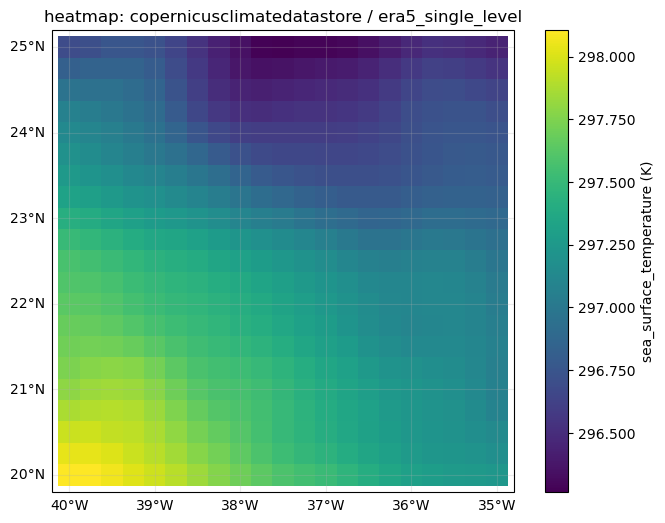


find-time
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'find-time',
 'predicate': 'gt',
 'filter_value': 297.6}

QueryResult
  query_id: c85159286f77391fd55b3c067e839ed7
  function: find-time
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: a01622840c54dfdaabc6d3dda165da4f
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/c85159286f77391fd55b3c067e839ed7/find-time/a01622840c54dfdaabc6d3dda165da4f.nc
	    units: 'K'
	    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '201

<xarray.Dataset> Size: 1kB
Dimensions:                  (timestamp: 31)
Coordinates:
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B '0001' '0001' ... '0001'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (timestamp) float64 248B 297.7 297.6 ... 296.6
    matches                  (timestamp) bool 31B True True True ... False False
Attributes:
    query_id:               c85159286f77391fd55b3c067e839ed7
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               find-time
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

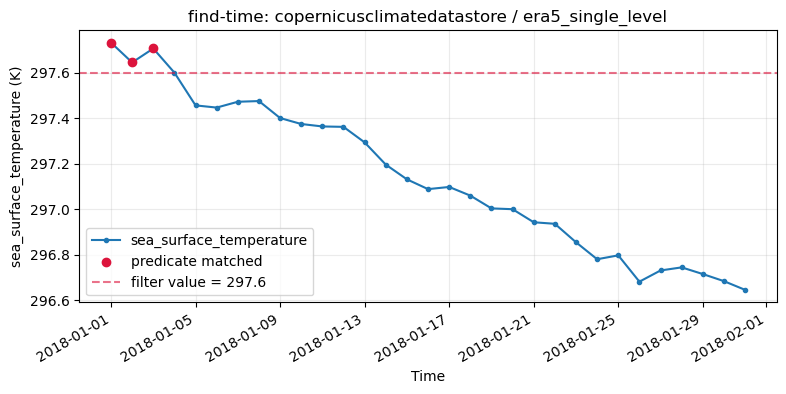


find-area
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': -40.0, 'east': -35.0, 'south': 20.0, 'north': 25.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'era5_single_level',
 'function': 'find-area',
 'predicate': 'gt',
 'filter_value': 298.0}

QueryResult
  query_id: cc12a416139bcd450c001cfc3cc81adf
  function: find-area
  warnings: []
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: a01622840c54dfdaabc6d3dda165da4f
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/cc12a416139bcd450c001cfc3cc81adf/find-area/a01622840c54dfdaabc6d3dda165da4f.nc
	    units: 'K'
	    hit_set: [('r3_c5', '2018-01-01T00:00:00'), ('r3_c5', '2018-01-02T00:00:00'), ('r3_c5', '2018-01-03T00:00:00'), ('r3_c5', '2018-01-04T00:00:00'), ('r3_c5', '2018-01-05T00:00:00'), ('r3_c5', '2018-01-06T00:00:00'), ('r3_c5', '2018-01-07T00:00:00'), ('r3_c5', '2018-01-08T00:00:00'), ('r3_c5', '2018-01-09T00:00:00'), ('r3_c5', '2018-01-10T00:00:00'), ('r3_c5', '2018-01-11T00:00:00'), ('r3_c5', '2018-01-12T00:00:00'), ('r3_c5', '2018-01-13T00:00:00'), ('r3_c5', '2018-01-14T00:00:00'), ('r3_c5', '2018-01-15T00:00:00'), ('r3_c5', '2018-01-16T00:00:00'), ('r3_c5', '2018-01-17T00:00:00'), ('r3_c5', '201

<xarray.Dataset> Size: 37kB
Dimensions:                  (cell: 441)
Coordinates:
  * cell                     (cell) int64 4kB 0 1 2 3 4 ... 436 437 438 439 440
    latitude                 (cell) float64 4kB 20.0 20.0 20.0 ... 25.0 25.0
    longitude                (cell) float64 4kB 320.0 320.2 ... 324.8 325.0
    bucket_id                (cell) <U1 2kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U12 21kB '20,320' '20,320.25' ... '25,325'
    number                   int64 8B 0
Data variables:
    sea_surface_temperature  (cell) float64 4kB 298.1 298.1 ... 296.5 296.4
    matches                  (cell) bool 441B True True True ... False False
Attributes:
    query_id:               cc12a416139bcd450c001cfc3cc81adf
    group_id:               a01622840c54dfdaabc6d3dda165da4f
    function:               find-area
    repository:             copernicusclimatedatastore
    dataset:                era5_single_level
    variable:               sea_surface_temperature
    additional_parameters:  {}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["d8a724491452e6cb1ee286d86055c56b"]

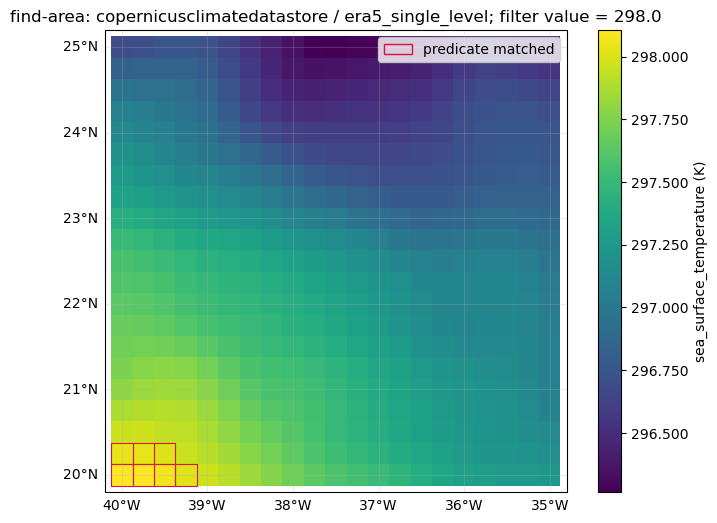

In [20]:
no_misses = run_scenario(NO_MISSES, FUNCTION_CALLS)

Calling CARRA dataset at a region that partially overlaps CARRA spatial domain. Expecting some tuples in `miss_set`.


get-data
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 60.0, 'east': 179.999, 'south': 65.0, 'north': 75.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'get-data'}

QueryResult
  query_id: ea2bf9536603309d20e72ad6deddff29
  function: get-data
  warnings: ['copernicusclimatedatastore/carra_height/sea_surface_temperature/{"height":"15m","region":"east"} is missing 31 of 62 bucket/time cells at the exact requested grid.']
  unmatched_miss_set: []
  groups: 1

  GroupResult 1
	    group_id: d1df36096318efad6597358087ce69e8
	    file_path: /Users/bean/Documents/school/research/current/polar-is/storage/data/tmp/query_results/ea2bf9536603309d20e72ad6deddff29/get-data/d1df36096318efad6597358087ce69e8.nc
	    units: 'K'
	    hit_set: [('r5_c1', '2018-01-01T00:00:00'), ('r5_c1', '2018-01-02T00:00:00'), ('r5_c1', '2018-01-03T00:00:00'), ('r5_c1', '2018-01-04T00:00:00'), ('r5_c1', '2018-01-05T00:00:00'), ('r5_c1', '2018-01-06T00:00:00'), ('r5_c1', '2018-01-07T00:00:00'), ('r5_c1', '2018-01-08T00:00:00'), ('r5_c1', '2018-01-09T00:00:00'), ('r5_c1', '2018-01-10T00:00:00'), ('r5_c1', '2018-01-11T00:00:00'), ('r5_c1', '2018-01-12T00:00:00'), ('r5_c1', '2018-01-13

<xarray.Dataset> Size: 9MB
Dimensions:                  (cell: 22447, timestamp: 31)
Coordinates:
  * cell                     (cell) int64 180kB 0 1 2 3 ... 22444 22445 22446
    latitude                 (cell) float64 180kB 74.99 74.96 ... 69.22 69.19
    longitude                (cell) float64 180kB 60.06 60.05 ... 65.27 65.26
    bucket_id                (cell) <U1 90kB 'r' 'r' 'r' 'r' ... 'r' 'r' 'r' 'r'
    cell_id                  (cell) <U27 2MB '74.9871532847,60.0577405395' .....
  * timestamp                (timestamp) datetime64[ns] 248B 2018-01-01 ... 2...
    expver                   (timestamp) <U4 496B 'prod' 'prod' ... 'prod'
Data variables:
    sea_surface_temperature  (timestamp, cell) float64 6MB 271.5 271.6 ... 271.5
Attributes:
    query_id:               ea2bf9536603309d20e72ad6deddff29
    group_id:               d1df36096318efad6597358087ce69e8
    function:               get-data
    repository:             copernicusclimatedatastore
    dataset:                carra_height
    variable:               sea_surface_temperature
    additional_parameters:  {"height": "15m", "region": "east"}
    coarseness_factor:      1
    time_unit:              Day
    aggregation_method:     mean
    block_ids:              ["afaa96a63416b0df4d654ea1fe51b743"]

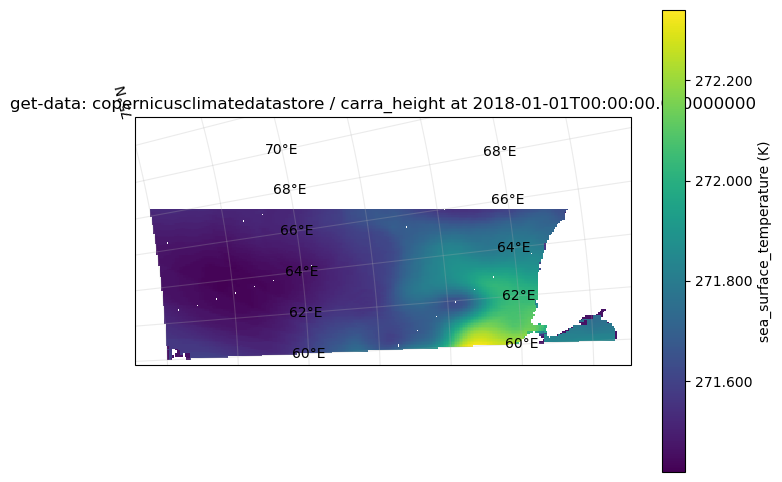

In [21]:
some_misses = run_scenario(SOME_MISSES, FUNCTION_CALLS[:1])

Calling CARRA dataset with a region that does not overlap CARRA spatial domain. No data should be returned.

In [24]:
all_misses = run_scenario(ALL_MISSES, FUNCTION_CALLS[:1])


get-data
Query input:


{'variable': 'sea_surface_temperature',
 'time_start': '2018-01',
 'time_end': '2018-01',
 'coarseness_factor': 1,
 'time_unit': 'Day',
 'aggregation_method': 'mean',
 'region': {'west': 10.0, 'east': 20.0, 'south': -20.0, 'north': -10.0},
 'repository': 'copernicusclimatedatastore',
 'dataset': 'carra_height',
 'additional_parameters': {'height': '15m'},
 'function': 'get-data'}

QueryResult
  query_id: aee2b6879994a55f53c3ed2483c691f4
  function: get-data
  warnings: ['No matching data blocks exist at the exact requested data grid. Try coarser spatial and/or temporal resolutions.']
  unmatched_miss_set: [('r2_c0', '2018-01-01T00:00:00'), ('r2_c0', '2018-01-02T00:00:00'), ('r2_c0', '2018-01-03T00:00:00'), ('r2_c0', '2018-01-04T00:00:00'), ('r2_c0', '2018-01-05T00:00:00'), ('r2_c0', '2018-01-06T00:00:00'), ('r2_c0', '2018-01-07T00:00:00'), ('r2_c0', '2018-01-08T00:00:00'), ('r2_c0', '2018-01-09T00:00:00'), ('r2_c0', '2018-01-10T00:00:00'), ('r2_c0', '2018-01-11T00:00:00'), ('r2_c0', '2018-01-12T00:00:00'), ('r2_c0', '2018-01-13T00:00:00'), ('r2_c0', '2018-01-14T00:00:00'), ('r2_c0', '2018-01-15T00:00:00'), ('r2_c0', '2018-01-16T00:00:00'), ('r2_c0', '2018-01-17T00:00:00'), ('r2_c0', '2018-01-18T00:00:00'), ('r2_c0', '2018-01-19T00:00:00'), ('r2_c0', '2018-01-20T00:00:00'), ('r2_c0', '2018-01-21T00:00:00'), ('r2_c0', '2018-01-22T00:00:00'), ('r2_c0', '2018-01-23T

## Query without specifying dataset

#### Define `func_calls` and `query`

In [34]:
FILTER_VAL_TIME = 277.9
FILTER_VAL_SPACE = 277.9

PREDICATE_TIME = 'le'
PREDICATE_SPACE = 'le'

FUNCTION_CALLS = (
    # ('get-data', {}),
    # ('timeseries', {}),
    # ('heatmap', {}),
    ('find-time', {'predicate': PREDICATE_TIME, 'filter_value': FILTER_VAL_TIME}),
    ('find-area', {'predicate': PREDICATE_SPACE, 'filter_value': FILTER_VAL_SPACE}),
)

COMMON_QUERY = {
    'variable': 'sea_surface_temperature',
    'time_start': '2018-01',
    'time_end': '2018-01',
    'coarseness_factor': 1,
    'time_unit': 'Day',
    'aggregation_method': 'mean',
}

# Parameters listed after **COMMON_QUERY will replace COMMON_QUERY value
REPO_SPECIFIED = {
    **COMMON_QUERY,
    'region': {'west': 20.0, 'east': 25.0, 'south': 70.0, 'north': 75.0},
    'repository': 'copernicusclimatedatastore',
    'time_unit': 'Source',
}

NO_REPO_SPECIFIED = {
    **COMMON_QUERY,
    'region': {'west': 20.0, 'east': 25.0, 'south': 70.0, 'north': 75.0},
    'time_unit': 'Source',
}

### Results

Specifying Copernicus Climate Data Store repository. Expecting ERA5 and CARRA datasets to return data.


find-time: 2 groups
  carra_height: Frozen({'timestamp': 248}), misses=0
  era5_single_level: Frozen({'timestamp': 744}), misses=0


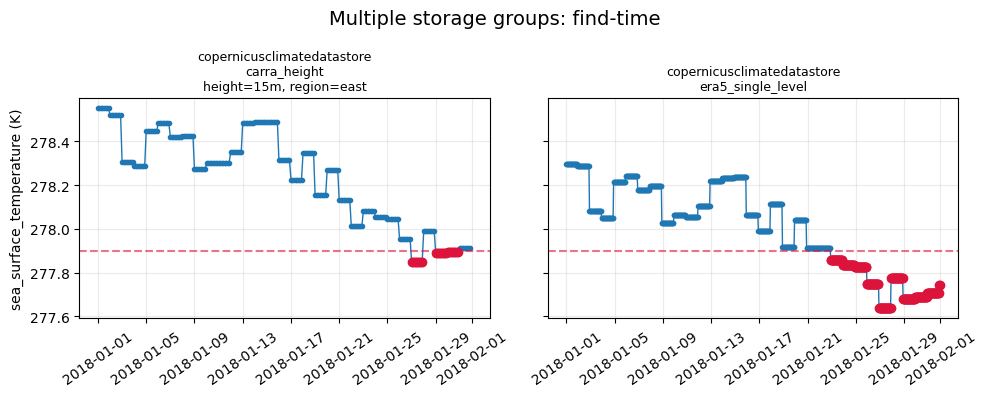


find-area: 2 groups
  carra_height: Frozen({'cell': 14055}), misses=0
  era5_single_level: Frozen({'cell': 396}), misses=0


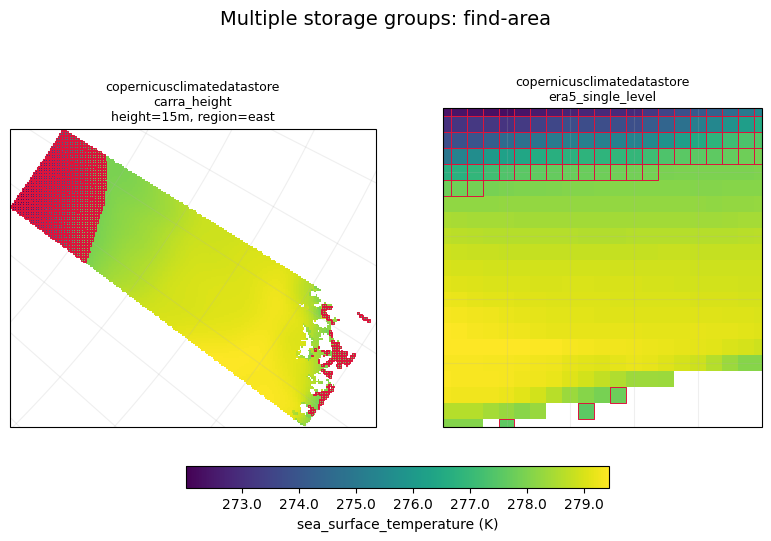

In [35]:
repo_specified = run_multigroup_scenario(REPO_SPECIFIED, FUNCTION_CALLS)

No repository is specified. Expecting all four datasets in storage to return data and be plotted together.


find-time: 4 groups
  carra_height: Frozen({'timestamp': 248}), misses=0
  emsst: Frozen({'timestamp': 31}), misses=0
  era5_single_level: Frozen({'timestamp': 744}), misses=0
  whoi_cdr: Frozen({'timestamp': 248}), misses=1


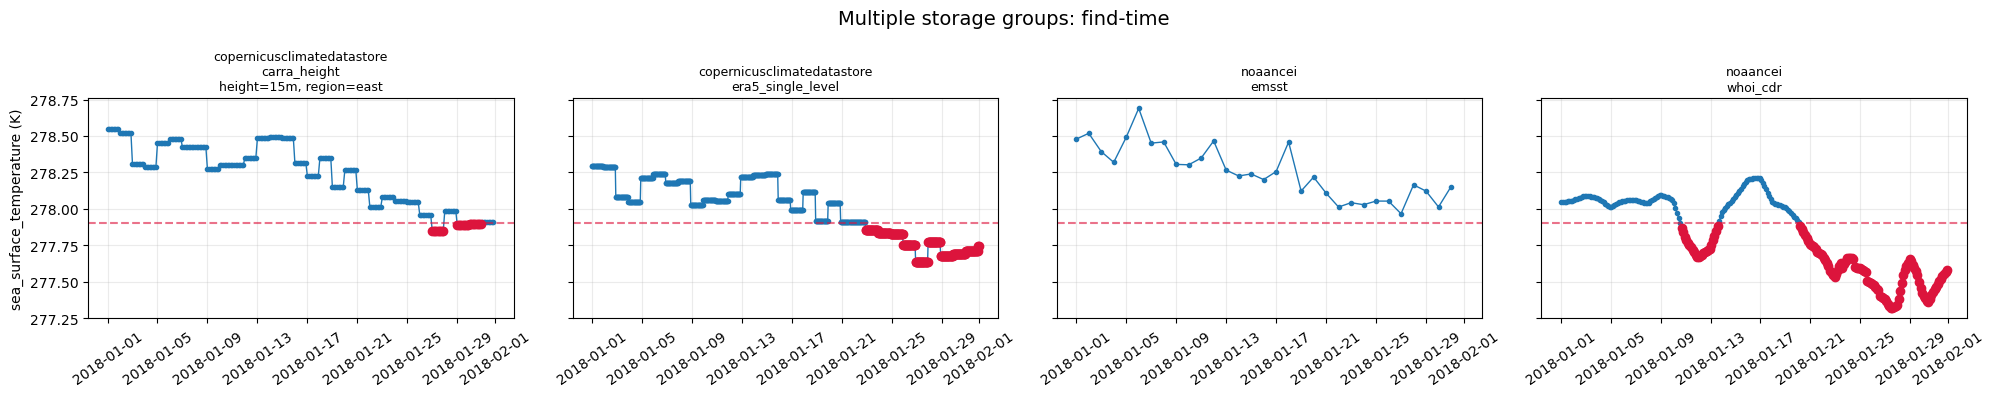


find-area: 4 groups
  carra_height: Frozen({'cell': 14055}), misses=0
  emsst: Frozen({'cell': 374}), misses=0
  era5_single_level: Frozen({'cell': 396}), misses=0
  whoi_cdr: Frozen({'cell': 368}), misses=1


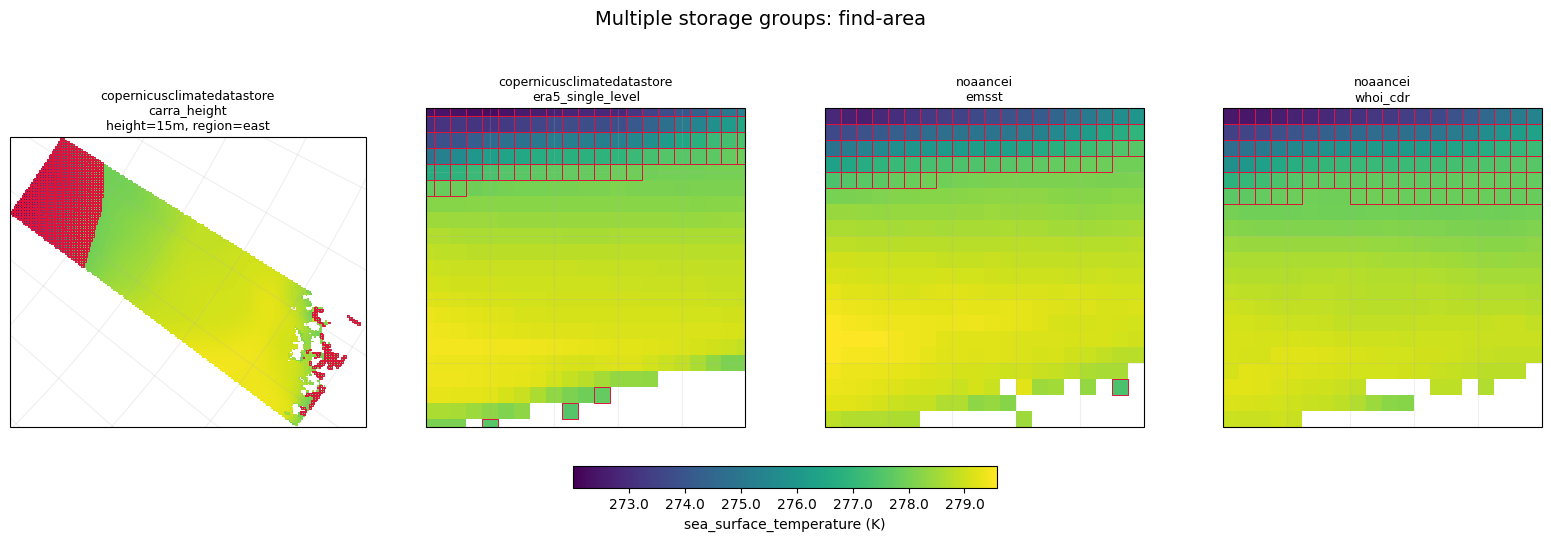

In [36]:
no_repo_specified = run_multigroup_scenario(NO_REPO_SPECIFIED, FUNCTION_CALLS)

## Plotting combined dataset

Each dataset in Polar-is is aggregated temporally to Hours, Days, Months, Years, or a subset of these that is coarser than their native temporal resolution.

Each temporal version of Polar-is is aggregated spatially by a factor of 2 and a factor of 4. This gives several levels of spatial resolution that may not overlap between groups, so we will also have one spatial resolution that all datasets are resampled (up- or down-sampled) to. This will be the data that we will use to calculate a combined dataset.

The spatial resolution all datasets are resampled to is defined as every 0.25 by 0.25 degree of a regular latitude-longitude projection (the same as the native resolution of ERA5). We call the transformed dataset **F**. Datasets with coarser resolutions will get upsampled to match this resolution. This can initially be done with simple imputation. Note that the original datasets are not replaced by the resampled/reprojected dataset. The transformed datasets will become a new "combined" dataset and be stored alongside the other datasets.

Once all datasets have the same spatial resolution, we can do the same thing but in the temporal dimension: resample all the datasets to the finest temporal resolution. Now, we are ready to combine the datasets.

For now, I want to combine the datasets by a simple weighted aggregate function (e.g. mean, but the aggregation method will be specified for each variable) where the weight for each dataset is a given constant. For the set of the union of the cell and timestamp pairs of all the datasets, the combined dataset is the (weighted) average of all the datasets available at each (cell, timestamp).

So it does not have to be computed each time, I want to keep things such as the source and target cell areas, cell corners/bounds, the sparse remapping matrix from each source grid to the target grid, the reliability-weight fields, etc. using the xESMF package.


For now, we are assuming datasets are all equally accurate.
For spatial resolution s and temporal resolution t, datasets A and B where the values of each dataset are A(x,y) B(x,y) the options for dataset A and B:

1. s(A) < s(B)
    * t(A) < t(B)
    * t(A) = t(B)
    * t(A) > t(B)
2. s(A) = s(B)
    * t(A) = t(B)




1. s(A) < s(B)
    * a. t(A) < t(B) - A is finer spatially and temporally, so we should use the values of A.
    * b. t(A) = t(B) - If s(A) * p < s(B) where p > 10, just use the values of A, otherwise, compute the weighted average [p(A(x,y)) + B(x,y)] / 2 for each cell (x,y).
    * c. t(A) > t(B) - Say s(A) * p < s(B) and p > 10. Say t(A) * q > t(B).
        * If q > 1, then A is much finer spatially but B is finer temporally. So, we will find the distribution of B(x,y) over time and then resample A(x,y) values over time so the values generate the distribution shape of B(x,y) (with the values of A). In other words, B sort of encodes the temporal behavior into A. This results in the combined dataset D having s(D) = s(A) and t(D) = t(B). This feels like something you could do with matrices?

2. s(A) = s(B)
    * t(A) < t(B) - If t(A) * p < t(B) where p > 10, just use the values of A, otherwise, compute the weighted average [p(A(x,y)) + B(x,y)] / 2 for each cell (x,y) (**same logic as 1b**).
    * t(A) = t(B) - Take the average [A(x,y), B(x,y)] / 2.
    * t(A) > t(B) - A and B have the same spatial resolution, but B is finer temporally. If t(A) > p * t(B) where p > 10, just use the values of B, otherwise, compute the weighted average [A(x,y), pB(x,y)] / 2 for each cell (x,y) (**same logic as 1b**).

3. s(A) > s(B)
    * t(A) < t(B) - A is finer temporally but B is finer spatially, so we can find the distribution of B(x,y) over space and then resample A(x,y) values over space so the values generate the same distribution shape of B(x,y). Then we find the distribution of A(x) over time and then resample the values of B over time in a similar manner. Then, we can just take an average of both these values (**similar logic as 1c**).
    * t(A) = t(B) - **same logic as 1b**
    * t(A) > t(B) - **same logic as 1a**

So essentially, we really have 

|             	| s(A) < s(B)                                                      	| s(A) = s(B)                                                      	| s(A) > s(B)                                           	|
|-------------	|------------------------------------------------------------------	|------------------------------------------------------------------	|-------------------------------------------------------	|
| t(A) < t(B) 	| A is finer temporally and spatially                              	| A is finer temporally,  A and B have the same spatial resolution 	| A is finer temporally,  A is coarser than B spatially 	|
| t(A) = t(B) 	| A and B have the same temporal resolution,  A is finer spatially 	| A and B have the same spatiotemporal grid                        	| -                                                     	|
| t(A) > t(B) 	| -                                                                	| -                                                                	| -                                                     	|
|             	|                                                                  	|                                                                  	|                                                       	|